# Pipelines - Revamped Version


ce notebook sert pour tester le backend des pipelines

# Initialisation

In [1]:
%pip install tqdm

Note: you may need to restart the kernel to use updated packages.


## Imports Librairies

In [2]:
import os
import sys
from tqdm import tqdm
import glob
import numpy as np
from PIL import Image
from sklearn.base import BaseEstimator, TransformerMixin, ClassifierMixin
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

import importlib
import inspect


"""import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)
"""



'import warnings\nfrom sklearn.exceptions import ConvergenceWarning\nwarnings.filterwarnings("ignore", category=ConvergenceWarning)\n'

## Ajouter le répertoire racine du projet au chemin Python ( à remplacer par toml)

In [3]:
project_root = os.path.abspath(os.path.join(os.getcwd(), '../..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

## Imports Features et Transformateurs

In [4]:
from src.features.Pipelines.loading_pipelines import *
from src.features.Pipelines.Transformateurs import *
from src.features.Pipelines.Visualisations import *

## Imports Visualisations

In [18]:
from src.features.Pipelines.Visualisations.Visu_Pipeline_Seed_Support import *
from src.features.Pipelines.Visualisations.Visu_Conf_Matrix import *

## Checkup Répertoire de Travail

In [5]:
print(f"\n📁 Chemin du projet ajouté: {project_root}")
print(f"📂 Répertoire de travail actuel: {os.getcwd()}")


📁 Chemin du projet ajouté: c:\Users\Léna\Documents\A_Repos\Data_Pipeline
📂 Répertoire de travail actuel: c:\Users\Léna\Documents\A_Repos\Data_Pipeline\src\notebooks


## Checkup Transformateurs (Optionnel)

In [6]:
from src.features.Pipelines.Visualisations.Visu_Pipeline_Seed_Support import *

print_transformers(project_root)

🔍 Découverte automatique des transformateurs:
ATTENTION: tensorflow_transformers.py a été refactorisé en modules séparés.
Utilisez les imports depuis les modules spécifiques ou depuis __init__.py
Les imports actuels fonctionnent toujours pour la compatibilité.

📁 Module: image_augmentation
------------------------------
  ✅ ImageAugmenter 🎲 (seed via constructor)
  ✅ ImageRandomCropper 🎲 (seed via constructor)

📁 Module: image_features
------------------------------
  ✅ ImageHistogram
  ✅ ImagePCA 🎲 (seed via constructor)
  ✅ ImageStandardScaler
  ✅ PCA 🎲 (seed via constructor)
  ✅ StandardScaler

📁 Module: image_loaders
------------------------------
  ✅ ImageLoader

📁 Module: image_preprocessing
------------------------------
  ✅ ImageBinarizer
  ✅ ImageFlattener
  ✅ ImageMasker
  ✅ ImageNormalizer
  ✅ ImageResizer

📁 Module: keras_classifiers
------------------------------
  ✅ LabelEncoder

📁 Module: tensorflow_data_augmenter
------------------------------
  ✅ TensorFlowDataAugmente

## Configs

### Variables Environnement

In [7]:
root_dir = '../../data/raw/COVID-19_Radiography_Dataset/COVID-19_Radiography_Dataset/'

In [8]:
seed = 42

# Main

## Chargement Paths

In [19]:
X, masks, y = load_paths_data_raw(root_dir)

In [20]:
print(f"Nombre d'images: {len(X)}")
print(f"Labels uniques: {set(y)}")

Nombre d'images: 21165
Labels uniques: {'viral pneumonia', 'lung_opacity', 'normal', 'covid'}


## Split des jeux de données

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=seed)
print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")

Train size: 16932, Test size: 4233


## Chargement des pipelines disponibles

In [22]:
# Découverte automatique des pipelines disponibles
registry_config = discover_available_pipelines(os.path.join(project_root, "src/features/Pipelines/Configs_Pipelines/"))
display_pipeline_structure(registry_config)

Pipelines disponibles:

Catégorie: BASIC

  simple: Pipeline simple pour classification rapide 
     Fichier: pipeline_simple.json


Catégorie: COMPOSITE

  composite_example: Pipeline composite utilisant d'autres pipelines comme sous-étapes 
     Fichier: pipeline_composite_example.json

  composite_no_viz: Pipeline composite sans visualisation (plus rapide pour les tests) 
     Fichier: pipeline_composite_no_viz.json


Catégorie: DATA_AUGMENTATION

  augmented: Pipeline avec augmentation de données et masquage 
     Fichier: pipeline_augmented.json


Catégorie: DEEP_LEARNING

  keras_full_pipeline: Pipeline complet utilisant TensorFlow pour l'augmentation et la classification 
     Fichier: keras_full_pipeline.json

  tensorflow_pipeline: Pipeline utilisant des transformateurs TensorFlow pour l'extraction de caractéristiques et la classification 
     Fichier: tensorflow_pipeline.json

  transfer_learning_pipeline: Pipeline utilisant le transfer learning avec un modèle pré-entraîné 


## ScrollBox Pipelines

In [ ]:

from src.features.Pipelines.Visualisations.Scrollbox_Transformateur_Notebook import *


display_transformers_in_scrollbox(project_root)

ImportError: cannot import name 'display_transformers_in_scrollbox' from 'src.features.Pipelines.Visualisations.Scrollbox_Transformateur_Notebook' (c:\Users\Léna\Documents\A_Repos\Data_Pipeline\src\features\Pipelines\Visualisations\Scrollbox_Transformateur_Notebook.py)

## Séléction Pipeline

In [23]:
# Chargement du pipeline par défaut avec seed
default_pipeline_name = "feature_engineering"

default_config = load_pipeline_config(registry_config[default_pipeline_name]["file"])
pipeline = create_pipeline_from_config(default_config, masks)

print(f"\nPipeline par défaut chargé:\n  {default_config['name']}")
print(f"\nDescription:\n  {default_config['description']}")
print(f"\nNombre d'étapes:\n  {len(pipeline.steps)}")

for step_name, step in pipeline.steps:
    print(f"  - Étape: {step_name} | Type: {type(step).__name__}")

# Appliquer la seed
set_pipeline_random_state(pipeline, seed)


Pipeline par défaut chargé:
  pipeline_feature_engineering

Description:
  Pipeline avec feature engineering avancé (histogrammes, PCA)

Nombre d'étapes:
  7
  - Étape: img_loader | Type: ImageLoader
  - Étape: img_resizer | Type: ImageResizer
  - Étape: img_normalizer | Type: ImageNormalizer
  - Étape: img_masker | Type: ImageMasker
  - Étape: img_flatten | Type: ImageFlattener
  - Étape: img_pca | Type: ImagePCA
  - Étape: clf | Type: LogisticRegression

🎲 Application de la seed 42 au pipeline:

  ⚠️  img_loader ne supporte pas random_state
  ⚠️  img_resizer ne supporte pas random_state
  ⚠️  img_normalizer ne supporte pas random_state
  ⚠️  img_masker ne supporte pas random_state
  ⚠️  img_flatten ne supporte pas random_state
  ✅ Seed 42 appliquée à img_pca
  ✅ Seed 42 appliquée à clf


In [24]:
pipeline

,steps,"[('img_loader', ...), ('img_resizer', ...), ...]"
,transform_input,None
,memory,None
,verbose,True
,img_size,"[256, 256]"
,mask_paths,"['../../data/raw/COVID-1...VID\\masks\\COVID-1.png', '../../data/raw/COVID-1...ID\\masks\\COVID-10.png', ...]"
,n_components,100
,random_state,42
,penalty,'l2'
,dual,False
,tol,0.0001


## Training Pipeline

Chargement de 16932 images :


Images: 100%|██████████| 16932/16932 [00:18<00:00, 899.75it/s]




Résolutions Uniques des images chargées :
 - (299, 299)
Chargement terminé.



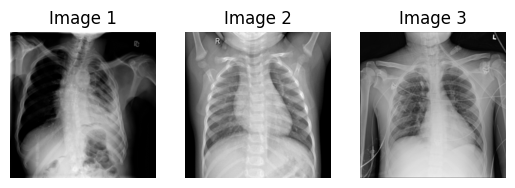

[Pipeline] ........ (step 1 of 7) Processing img_loader, total=  18.9s

Redimensionnement de 16932 images en [256, 256] ...


Redimensionnement: 100%|██████████| 16932/16932 [00:08<00:00, 1923.22it/s]



Redimensionnement terminé.


Résolutions Uniques des images après redimensionnement :
 - (256, 256)



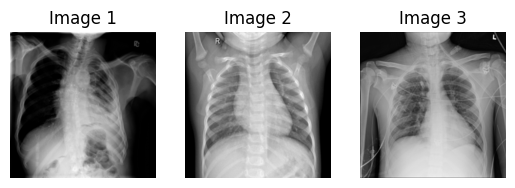

[Pipeline] ....... (step 2 of 7) Processing img_resizer, total=   9.3s

Normalisation de 16932 images ...
Normalisation terminée.

Normalisation terminée.



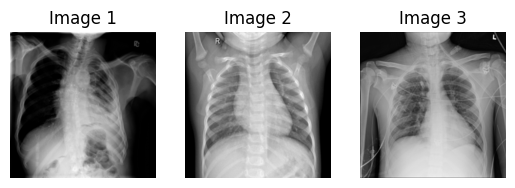

[Pipeline] .... (step 3 of 7) Processing img_normalizer, total=   3.4s

Application des masques sur 16932 images ...


Masquage: 100%|██████████| 16932/16932 [00:07<00:00, 2162.76it/s]

Masquage terminé.



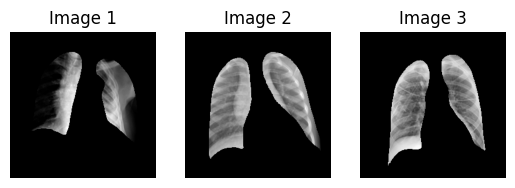

[Pipeline] ........ (step 4 of 7) Processing img_masker, total=   9.5s

Aplatissement de 16932 images ...


Aplatissement: 100%|██████████| 16932/16932 [00:01<00:00, 10290.92it/s]



Aplatissement terminé.

[Pipeline] ....... (step 5 of 7) Processing img_flatten, total=   3.2s

🔬 Analyse en Composantes Principales (PCA)
📊 Nombre de composantes: 100

📈 Variance expliquée par composante:

🔬 Analyse en Composantes Principales (PCA)
📊 Nombre de composantes: 100

📈 Variance expliquée par composante:


,Composante,Variance_Expliquée,Variance_Expliquée_%,Variance_Cumulée,Variance_Cumulée_%
0,PC1,0.1273,12.73,0.1273,12.730000
1,PC2,0.1218,12.18,0.2492,24.920000
2,PC3,0.1103,11.03,0.3595,35.950001
3,PC4,0.0586,5.86,0.4181,41.810001
4,PC5,0.0353,3.53,0.4534,45.340000
5,PC6,0.0288,2.88,0.4822,48.220001
6,PC7,0.0251,2.51,0.5072,50.720001
7,PC8,0.0200,2.00,0.5273,52.730000
8,PC9,0.0181,1.81,0.5454,54.540001
9,PC10,0.0155,1.55,0.5609,56.090000



... (80 composantes supplémentaires)

📈 Variance totale expliquée: 0.8312 (83.12%)


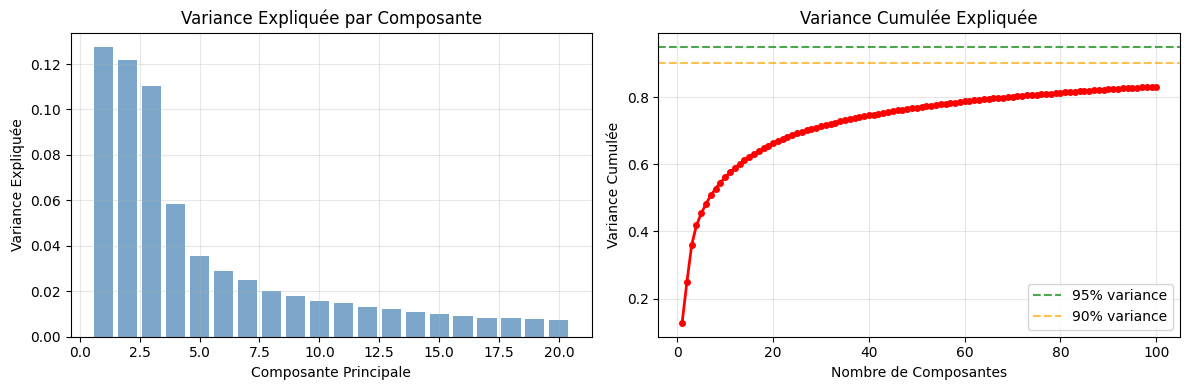


🎲 Visualisation 3D de l'espace PCA:



✅ Visualisations interactives créées !

💡 Utilisez le slider ci-dessus pour explorer les images et leur position PCA

[Pipeline] ........... (step 6 of 7) Processing img_pca, total=  35.4s


c:\Users\Léna\Documents\A_Repos\Data_Pipeline\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:470: ConvergenceWarning:

lbfgs failed to converge after 150 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=150).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression

[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.6s finished


[Pipeline] ............... (step 7 of 7) Processing clf, total=   0.7s


,steps,"[('img_loader', ...), ('img_resizer', ...), ...]"
,transform_input,None
,memory,None
,verbose,True
,img_size,"[256, 256]"
,mask_paths,"['../../data/raw/COVID-1...VID\\masks\\COVID-1.png', '../../data/raw/COVID-1...ID\\masks\\COVID-10.png', ...]"
,n_components,100
,random_state,42
,penalty,'l2'
,dual,False
,tol,0.0001


In [25]:
# Entraînement du pipeline composite
pipeline.fit(X_train, y_train)

## Prédiction Pipeline

Chargement de 4233 images :


Images: 100%|██████████| 4233/4233 [00:04<00:00, 893.94it/s]




Résolutions Uniques des images chargées :
 - (299, 299)
Chargement terminé.



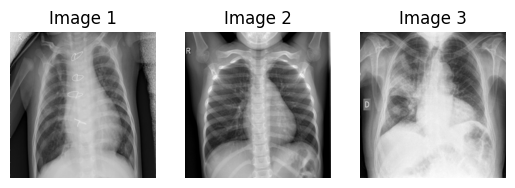


Redimensionnement de 4233 images en [256, 256] ...


Redimensionnement: 100%|██████████| 4233/4233 [00:02<00:00, 1905.99it/s]



Redimensionnement terminé.


Résolutions Uniques des images après redimensionnement :
 - (256, 256)



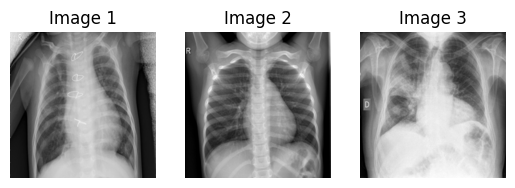


Normalisation de 4233 images ...
Normalisation terminée.

Normalisation terminée.



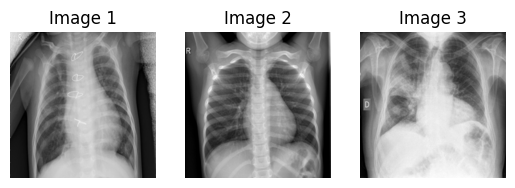


Application des masques sur 4233 images ...


Masquage: 100%|██████████| 4233/4233 [00:01<00:00, 2168.20it/s]



Masquage terminé.



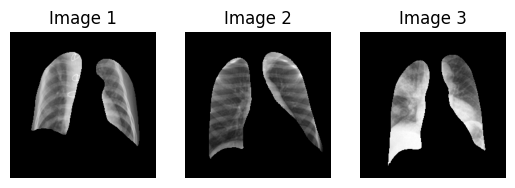


Aplatissement de 4233 images ...


Aplatissement: 100%|██████████| 4233/4233 [00:00<00:00, 10142.51it/s]



Aplatissement terminé.


🔬 Analyse en Composantes Principales (PCA)
📊 Nombre de composantes: 100

📈 Variance expliquée par composante:

🔬 Analyse en Composantes Principales (PCA)
📊 Nombre de composantes: 100

📈 Variance expliquée par composante:


,Composante,Variance_Expliquée,Variance_Expliquée_%,Variance_Cumulée,Variance_Cumulée_%
0,PC1,0.1273,12.73,0.1273,12.730000
1,PC2,0.1218,12.18,0.2492,24.920000
2,PC3,0.1103,11.03,0.3595,35.950001
3,PC4,0.0586,5.86,0.4181,41.810001
4,PC5,0.0353,3.53,0.4534,45.340000
5,PC6,0.0288,2.88,0.4822,48.220001
6,PC7,0.0251,2.51,0.5072,50.720001
7,PC8,0.0200,2.00,0.5273,52.730000
8,PC9,0.0181,1.81,0.5454,54.540001
9,PC10,0.0155,1.55,0.5609,56.090000



... (80 composantes supplémentaires)

📈 Variance totale expliquée: 0.8312 (83.12%)


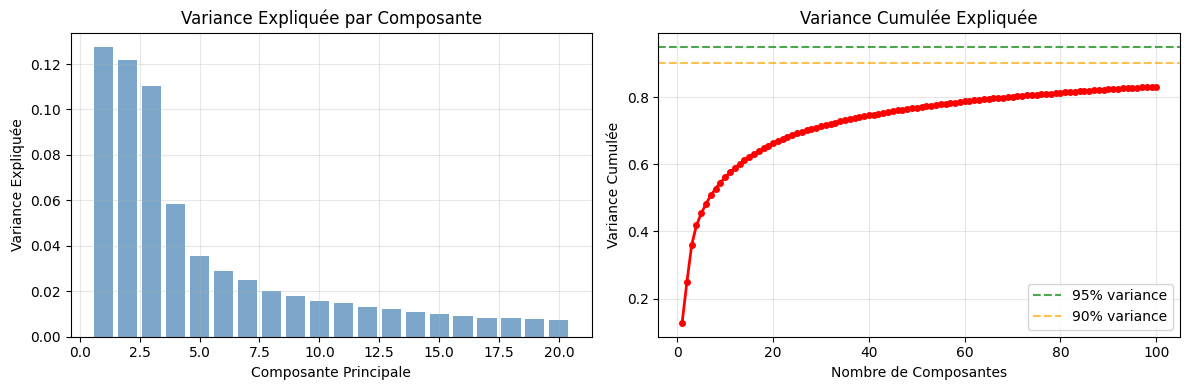


🎲 Visualisation 3D de l'espace PCA:



✅ Visualisations interactives créées !

💡 Utilisez le slider ci-dessus pour explorer les images et leur position PCA



In [26]:
# Prédiction
y_pred = pipeline.predict(X_test)

## Matrice De Confusion

In [27]:
# Matrice de confusion visuelle
plot_confusion_matrix(y_test, y_pred)


NameError: name 'plot_confusion_matrix' is not defined

## Quelques exemples d'images (Vrai vs. Prédit)

In [ ]:
# Afficher quelques images test avec prédiction et vrai label
nbr_images = 3
for i in range(nbr_images):
    img = Image.open(X_test[i])
    plt.imshow(img, cmap='gray')
    plt.title(f"Vrai: {y_test[i]} / Prédit: {y_pred[i]}")
    plt.axis('off')
    plt.show()